In [ ]:
from google.colab import drive
import os

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Create a persistent directory for this assignment
persistent_path = '/content/drive/MyDrive/ATML_Assignment_0'
os.makedirs(f'{persistent_path}/data', exist_ok=True)
os.makedirs(f'{persistent_path}/assets', exist_ok=True)

print(f"\nEnvironment secured! All files will be saved to: {persistent_path}")

Mounted at /content/drive

Environment secured! All files will be saved to: /content/drive/MyDrive/ATML_Assignment_0


In [ ]:
import torch
import torchvision.transforms as T
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image
import requests
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
persistent_path = '/content/drive/MyDrive/ATML_Assignment_0'

print("1. Loading Pre-trained ViT-Base (Patch 16)...")
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights).to(device)
model.eval()
preprocess = weights.transforms()

print("2. Cleaning up corrupted files and downloading new images...")
# Using bulletproof raw GitHub URLs that do not block requests
image_urls = {
    "dog": "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "sports_car": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n04285008_sports_car.JPEG"
}

image_paths = []
for name, url in image_urls.items():
    path = f"{persistent_path}/assets/{name}.jpg"

    # Force delete the corrupted file if it exists so we can start fresh
    if os.path.exists(path):
        os.remove(path)

    # Download fresh from the unblocked sources
    response = requests.get(url)
    with open(path, 'wb') as f:
        f.write(response.content)

    image_paths.append((name, path))

print("3. Running Inference...")
categories = weights.meta["categories"]

for name, path in image_paths:
    img = Image.open(path).convert('RGB')
    batch = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(batch).squeeze(0).softmax(0)

    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = categories[class_id]
    print(f"Image: {name} | Top-1 Prediction: {category_name} | Confidence: {score*100:.2f}%")

1. Loading Pre-trained ViT-Base (Patch 16)...
2. Cleaning up corrupted files and downloading new images...
3. Running Inference...
Image: dog | Top-1 Prediction: Samoyed | Confidence: 79.97%
Image: sports_car | Top-1 Prediction: sports car | Confidence: 55.78%


1. Loading Pre-trained ViT-Base...
2. Generating Attention Heatmaps...


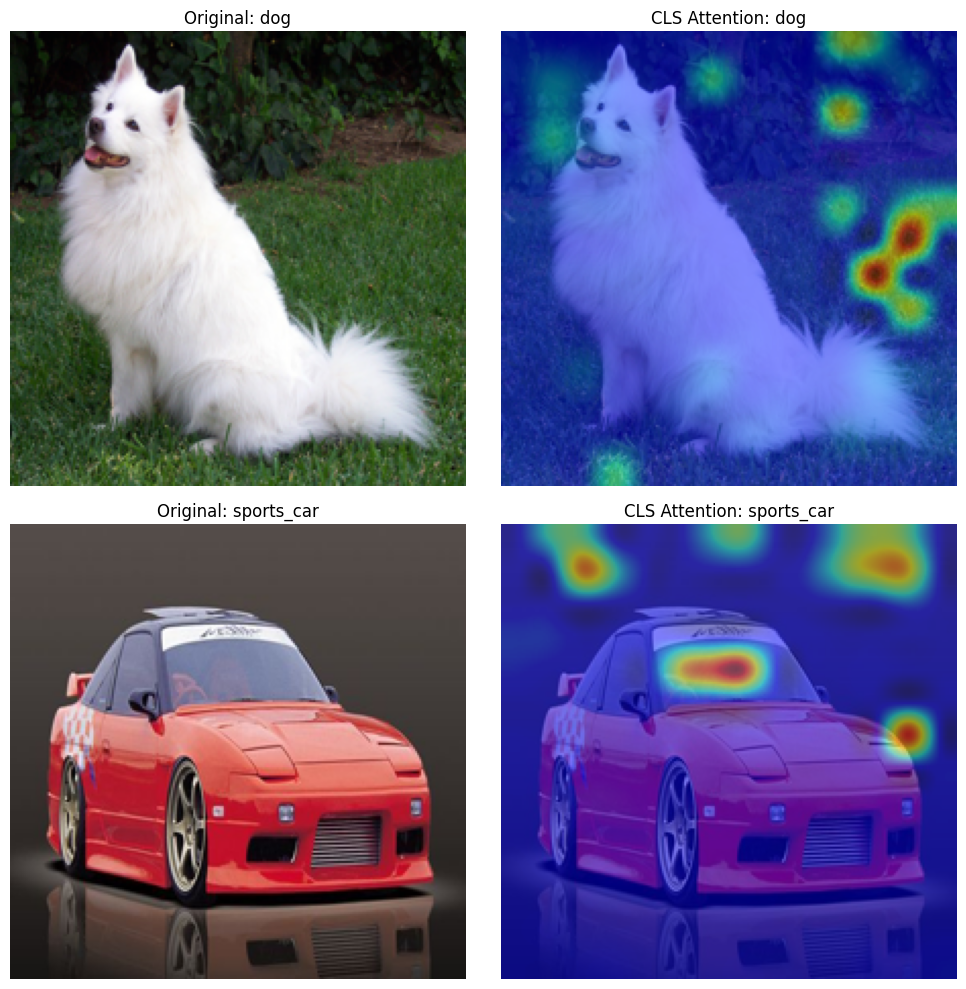

In [ ]:
import torch
import torchvision.transforms as T
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
persistent_path = '/content/drive/MyDrive/ATML_Assignment_0'

print("1. Loading Pre-trained ViT-Base...")
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights).to(device)
model.eval()
preprocess = weights.transforms()

# 2. Monkey-patch to extract attention weights
attention_weights_dict = {}
original_mha_forward = model.encoder.layers[-1].self_attention.forward

def hooked_mha_forward(*args, **kwargs):
    # Force the multihead attention to return its internal weights
    kwargs['need_weights'] = True
    kwargs['average_attn_weights'] = True
    attn_output, attn_weights = original_mha_forward(*args, **kwargs)
    attention_weights_dict['last_layer'] = attn_weights
    return attn_output, attn_weights

# Apply the patch to the final encoder block
model.encoder.layers[-1].self_attention.forward = hooked_mha_forward

print("2. Generating Attention Heatmaps...")
image_paths = [
    ("dog", f"{persistent_path}/assets/dog.jpg"),
    ("sports_car", f"{persistent_path}/assets/sports_car.jpg")
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for idx, (name, path) in enumerate(image_paths):
    # Load and preprocess
    img = Image.open(path).convert('RGB')
    batch = preprocess(img).unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        model(batch)

    # 3. Extract CLS attention to spatial patches
    # The output shape is [1, 197, 197]. Index 0 is the CLS token.
    # Indices 1 to 196 are the 14x14 image patches.
    attn = attention_weights_dict['last_layer'][0, 0, 1:].cpu().numpy()

    # Reshape the 196 patches back into a 14x14 grid
    attn = attn.reshape(14, 14)

    # Normalize for visualization
    attn = (attn - attn.min()) / (attn.max() - attn.min())
    attn_resized = cv2.resize(attn, (224, 224), interpolation=cv2.INTER_CUBIC)

    # Plot Original Image
    img_resized = img.resize((224, 224))
    axes[idx, 0].imshow(img_resized)
    axes[idx, 0].set_title(f"Original: {name}")
    axes[idx, 0].axis('off')

    # Plot Heatmap Overlay
    axes[idx, 1].imshow(img_resized)
    axes[idx, 1].imshow(attn_resized, cmap='jet', alpha=0.5)
    axes[idx, 1].set_title(f"CLS Attention: {name}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

Testing ViT Robustness with 50% Patch Masking...


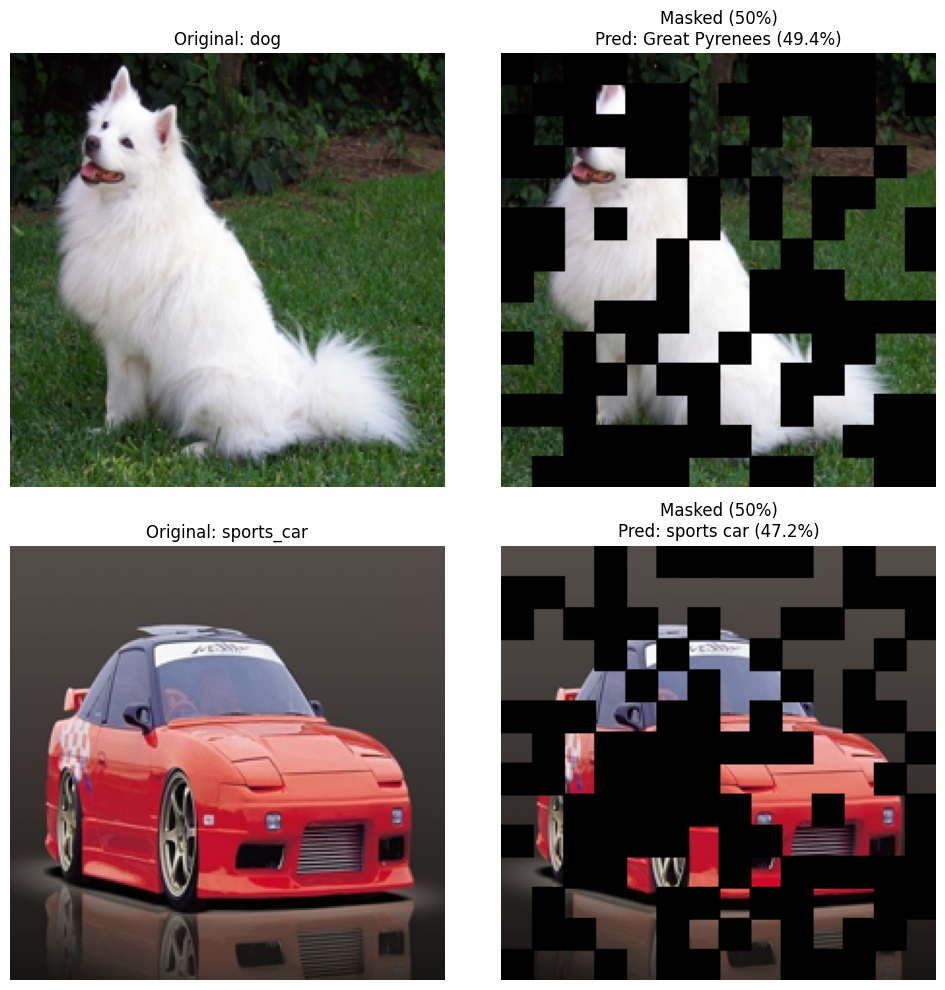

In [ ]:
import torch
import torchvision.transforms as T
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
persistent_path = '/content/drive/MyDrive/ATML_Assignment_0'

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights).to(device)
model.eval()
preprocess = weights.transforms()
categories = weights.meta["categories"]

image_paths = [
    ("dog", f"{persistent_path}/assets/dog.jpg"),
    ("sports_car", f"{persistent_path}/assets/sports_car.jpg")
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

def mask_image(img, mask_ratio=0.5, patch_size=16):
    # Resize to match ViT input exactly to make masking math seamless
    img = img.resize((224, 224))
    masked_img = img.copy()
    draw = ImageDraw.Draw(masked_img)

    num_patches_1d = 224 // patch_size
    total_patches = num_patches_1d ** 2
    num_mask = int(total_patches * mask_ratio)

    # Randomly select which patches to black out
    mask_indices = random.sample(range(total_patches), num_mask)

    for idx in mask_indices:
        row = idx // num_patches_1d
        col = idx % num_patches_1d
        x0 = col * patch_size
        y0 = row * patch_size
        x1 = x0 + patch_size
        y1 = y0 + patch_size
        draw.rectangle([x0, y0, x1, y1], fill="black")

    return masked_img

print("Testing ViT Robustness with 50% Patch Masking...")

for idx, (name, path) in enumerate(image_paths):
    img = Image.open(path).convert('RGB')
    masked_img = mask_image(img, mask_ratio=0.5)

    batch = preprocess(masked_img).unsqueeze(0).to(device)
    with torch.no_grad():
        prediction = model(batch).squeeze(0).softmax(0)

    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = categories[class_id]

    # Plot Original
    axes[idx, 0].imshow(img.resize((224, 224)))
    axes[idx, 0].set_title(f"Original: {name}")
    axes[idx, 0].axis('off')

    # Plot Masked & Prediction
    axes[idx, 1].imshow(masked_img)
    axes[idx, 1].set_title(f"Masked (50%)\nPred: {category_name} ({score*100:.1f}%)")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## Task 3
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"1. Initializing CLIP on {device}...")

# Load the model and processor from Hugging Face
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

print("2. Downloading test image...")
# Let's use a picture of an astronaut riding a horse
url = "https://images.unsplash.com/photo-1541185933-ef5d8ed016c2?q=80&w=800&auto=format&fit=crop"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

print("3. Setting up custom text prompts...")
# We can literally type anything here
prompts = [
    "a photo of a space rocket",
    "an astronaut riding a horse on mars",
    "a person walking a dog in the park",
    "a standard portrait of a man"
]

print("4. Running Zero-Shot Inference...")
# Process the image and the text together
inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Get the image-text similarity scores and convert them to probabilities
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

print("\n--- CLIP Zero-Shot Predictions ---")
for prompt, prob in zip(prompts, probs):
    print(f"'{prompt}': {prob * 100:.2f}%")

1. Initializing CLIP on cpu...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

2. Downloading test image...
3. Setting up custom text prompts...
4. Running Zero-Shot Inference...

--- CLIP Zero-Shot Predictions ---
'a photo of a space rocket': 99.61%
'an astronaut riding a horse on mars': 0.39%
'a person walking a dog in the park': 0.00%
'a standard portrait of a man': 0.00%


Hardware: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Computing patch-level similarity...


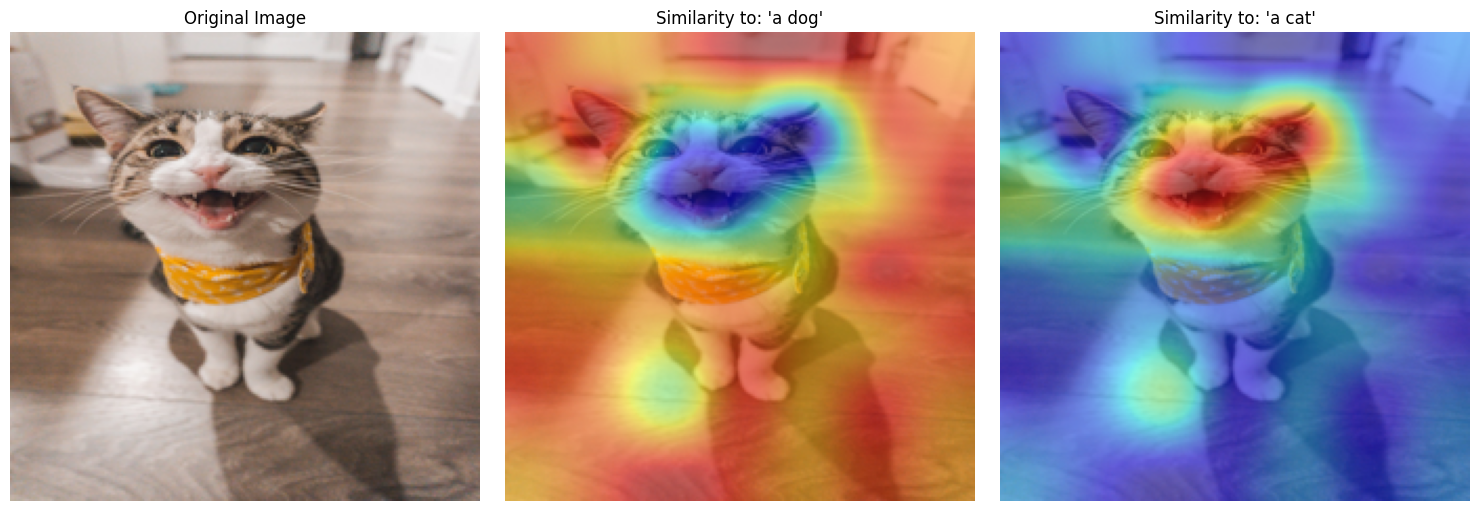

In [ ]:
#task 3.2
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware: {device}")

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

# Download an image with distinct subjects (a dog and a cat)
url = "https://images.unsplash.com/photo-1543852786-1cf6624b9987?q=80&w=800&auto=format&fit=crop"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image = image.resize((224, 224))

prompts = ["a dog", "a cat"]

# 1. Process the full image and text to get baseline embeddings
inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)
    text_features = outputs.text_embeds
    text_features /= text_features.norm(dim=-1, keepdim=True)

# 2. Chop the image into a 7x7 grid (patches)
patch_size = 32
grid_size = 224 // patch_size
heatmaps = {prompt: np.zeros((grid_size, grid_size)) for prompt in prompts}

print("Computing patch-level similarity...")
for i in range(grid_size):
    for j in range(grid_size):
        # Extract the patch
        left = j * patch_size
        upper = i * patch_size
        right = left + patch_size
        lower = upper + patch_size
        patch = image.crop((left, upper, right, lower))

        patch_resized = patch.resize((224, 224))

        # THE FIX: Pass dummy text so we can use the standard forward pass that we know works
        patch_input = processor(text=["dummy"], images=patch_resized, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            patch_outputs = model(**patch_input)
            patch_features = patch_outputs.image_embeds
            patch_features /= patch_features.norm(dim=-1, keepdim=True)

        # Compute cosine similarity between the patch and the text prompts
        similarity = (100.0 * patch_features @ text_features.T).softmax(dim=-1)

        # Store the similarity scores in our heatmap grid
        for idx, prompt in enumerate(prompts):
            heatmaps[prompt][i, j] = similarity[0][idx].item()

# 3. Plot the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

for idx, prompt in enumerate(prompts):
    heatmap = heatmaps[prompt]
    heatmap_resized = cv2.resize(heatmap, (224, 224), interpolation=cv2.INTER_CUBIC)

    axes[idx + 1].imshow(image)
    axes[idx + 1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[idx + 1].set_title(f"Similarity to: '{prompt}'")
    axes[idx + 1].axis("off")

plt.tight_layout()
plt.show()

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


Starting VAE Training...
Epoch: 1 | Average Loss: 189.1838
Epoch: 2 | Average Loss: 167.3043
Epoch: 3 | Average Loss: 163.7308
Epoch: 4 | Average Loss: 161.7659
Epoch: 5 | Average Loss: 160.2855
Epoch: 6 | Average Loss: 159.0617
Epoch: 7 | Average Loss: 157.9232
Epoch: 8 | Average Loss: 157.0151
Epoch: 9 | Average Loss: 156.1950
Epoch: 10 | Average Loss: 155.4701
Epoch: 11 | Average Loss: 154.8688
Epoch: 12 | Average Loss: 154.2921
Epoch: 13 | Average Loss: 153.7512
Epoch: 14 | Average Loss: 153.2994
Epoch: 15 | Average Loss: 152.9058

Training Complete! Generating Visualizations...


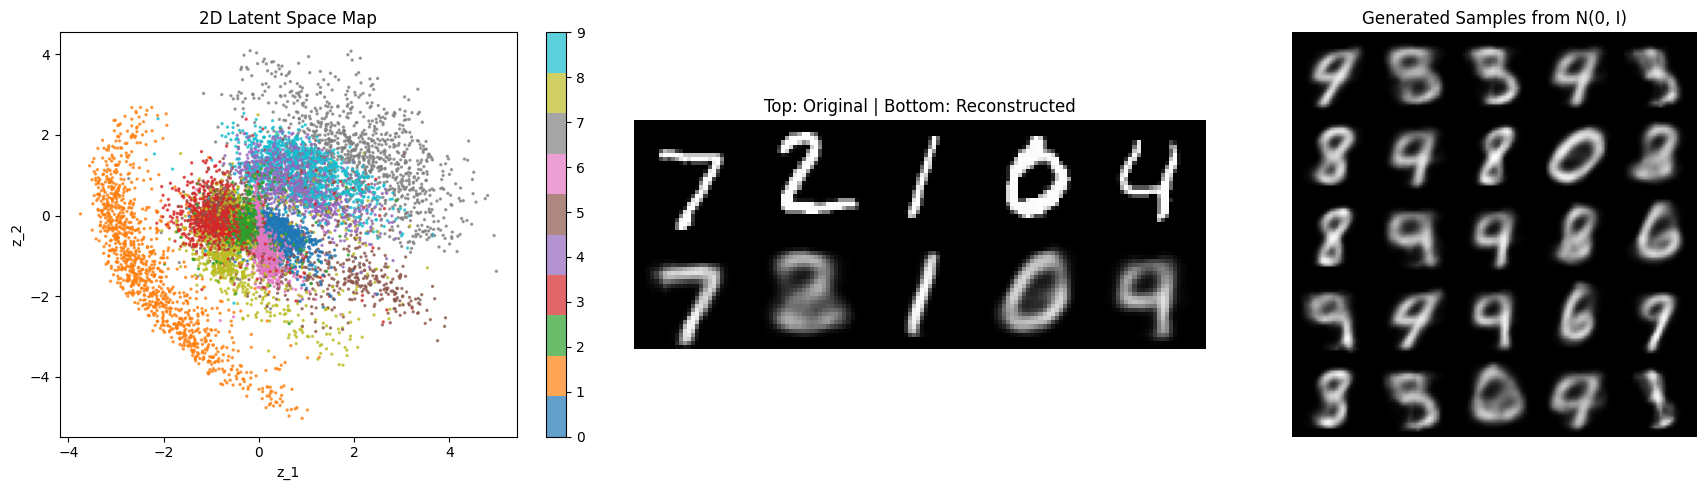

In [ ]:
#task4
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
batch_size = 128
epochs = 15
learning_rate = 1e-3
latent_dim = 2  # Set to 2 for direct 2D visualization

# MNIST Dataset
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# 1. VAE Model Definition
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss Function: Negative ELBO (BCE + KL Divergence)
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Training Loop
print("Starting VAE Training...")
model.train()
for epoch in range(1, epochs + 1):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch: {epoch} | Average Loss: {avg_loss:.4f}')

print("\nTraining Complete! Generating Visualizations...")

# Evaluation and Visualizations
model.eval()

# 2a. Latent Space Visualization
all_mu = []
all_labels = []
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Latent Space
scatter = axes[0].scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.7, s=2)
axes[0].set_title("2D Latent Space Map")
axes[0].set_xlabel("z_1")
axes[0].set_ylabel("z_2")
fig.colorbar(scatter, ax=axes[0])

# 2b. Reconstruction Quality
data, _ = next(iter(test_loader))
data = data.to(device)
with torch.no_grad():
    recon, _, _ = model(data)

recon = recon.view(batch_size, 1, 28, 28).cpu()
data = data.cpu()

n = 5
orig_img = np.concatenate([data[i][0].numpy() for i in range(n)], axis=1)
recon_img = np.concatenate([recon[i][0].numpy() for i in range(n)], axis=1)
comparison = np.concatenate([orig_img, recon_img], axis=0)

axes[1].imshow(comparison, cmap='gray')
axes[1].set_title("Top: Original | Bottom: Reconstructed")
axes[1].axis('off')

# 2c. Generation of New Samples
with torch.no_grad():
    z = torch.randn(25, latent_dim).to(device)
    generated_imgs = model.decode(z).view(-1, 1, 28, 28).cpu()

gen_grid = np.concatenate(
    [np.concatenate([generated_imgs[i*5 + j][0].numpy() for j in range(5)], axis=1)
     for i in range(5)],
    axis=0
)

axes[2].imshow(gen_grid, cmap='gray')
axes[2].set_title("Generated Samples from N(0, I)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Hardware: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Extracting Text Embeddings...
Extracting Image Embeddings (STL-10 Test Set)...


100%|██████████| 32/32 [00:36<00:00,  1.14s/it]



--- Task 3.1: Zero-Shot Accuracies ---
Plain labels: 0.9625
Photo prompts: 0.9736
Detailed prompts: 0.9674
Contextual prompts: 0.9645

--- Task 3.3: Aligned Accuracy (Photo Prompts) ---
Aligned Accuracy: 0.9685

Generating t-SNE Visualizations...


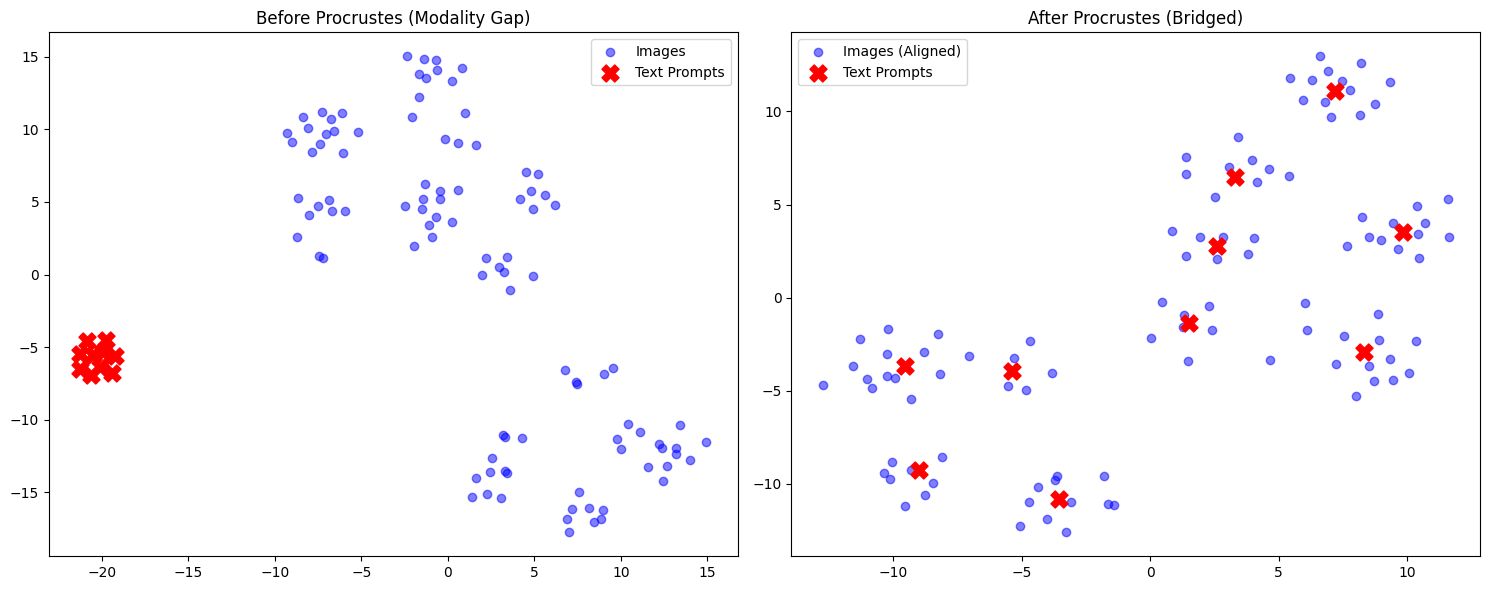

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from transformers import CLIPProcessor, CLIPModel
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware: {device}")

# 1. Load CLIP Model
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

# 2. Load STL-10 Test Set
dataset = datasets.STL10(root='./data', split='test', download=True)
classes = dataset.classes

# 3. Prepare Prompt Strategies
prompt_strategies = {
    "Plain labels": [f"{c}" for c in classes],
    "Photo prompts": [f"a photo of a {c}" for c in classes],
    "Detailed prompts": [f"a high-resolution photo of a {c}" for c in classes],
    "Contextual prompts": [f"a picture taken in the wild of a {c}" for c in classes]
}

text_embeds_dict = {}
dummy_image = Image.new('RGB', (224, 224))

print("Extracting Text Embeddings...")
with torch.no_grad():
    for name, prompts in prompt_strategies.items():
        # THE FIX: Use dummy images to force the standard forward pass that we know works
        inputs = processor(text=prompts, images=[dummy_image]*len(prompts), return_tensors="pt", padding=True).to(device)
        outputs = model(**inputs)
        embeds = outputs.text_embeds
        text_embeds_dict[name] = embeds / embeds.norm(dim=-1, keepdim=True)

# 4. Extract Image Embeddings for the entire test set (8,000 images)
def collate_fn(batch):
    images, labels = zip(*batch)
    return images, torch.tensor(labels)

loader = DataLoader(dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

all_image_embeds = []
all_labels = []

print("Extracting Image Embeddings (STL-10 Test Set)...")
with torch.no_grad():
    for images, labels in tqdm(loader):
        # THE FIX: Use dummy text to force the standard forward pass
        dummy_text = ["dummy"] * len(images)
        inputs = processor(text=dummy_text, images=images, return_tensors="pt", padding=True).to(device)

        outputs = model(**inputs)
        img_embed = outputs.image_embeds
        img_embed = img_embed / img_embed.norm(dim=-1, keepdim=True)

        all_image_embeds.append(img_embed)
        all_labels.append(labels)

all_image_embeds = torch.cat(all_image_embeds, dim=0)
all_labels = torch.cat(all_labels, dim=0).to(device)

# --- Task 3.1: Zero-Shot Classification ---
print("\n--- Task 3.1: Zero-Shot Accuracies ---")
for name, text_embeds in text_embeds_dict.items():
    logits = 100.0 * all_image_embeds @ text_embeds.T
    preds = logits.argmax(dim=-1)
    acc = (preds == all_labels).float().mean().item()
    print(f"{name}: {acc:.4f}")

# --- Task 3.2 & 3.3 Modality Gap & Procrustes Alignment ---
# We sample 100 images for the visualization and Procrustes fit to keep it mathematically clean
vis_img_embeds = all_image_embeds[:100].cpu().numpy()
vis_labels = all_labels[:100].cpu().numpy()
base_text_embeds = text_embeds_dict["Photo prompts"].cpu().numpy()

# Match each image to its correct text embedding to find the rotation matrix
matched_text_embeds = np.array([base_text_embeds[lbl] for lbl in vis_labels])

# Calculate Orthogonal Procrustes
R, scale = orthogonal_procrustes(vis_img_embeds, matched_text_embeds)

# Apply rotation to ALL image embeddings
aligned_all_img_embeds = (all_image_embeds.cpu().numpy() @ R)
aligned_all_img_embeds = torch.tensor(aligned_all_img_embeds).to(device)
aligned_all_img_embeds = aligned_all_img_embeds / aligned_all_img_embeds.norm(dim=-1, keepdim=True)

print("\n--- Task 3.3: Aligned Accuracy (Photo Prompts) ---")
logits_aligned = 100.0 * aligned_all_img_embeds @ text_embeds_dict["Photo prompts"].T
preds_aligned = logits_aligned.argmax(dim=-1)
acc_aligned = (preds_aligned == all_labels).float().mean().item()
print(f"Aligned Accuracy: {acc_aligned:.4f}")

# --- Visualization (t-SNE) ---
print("\nGenerating t-SNE Visualizations...")
tsne = TSNE(n_components=2, perplexity=15, random_state=42)

# Unaligned visualization
combined_unaligned = np.vstack([vis_img_embeds, base_text_embeds])
tsne_unaligned = tsne.fit_transform(combined_unaligned)

# Aligned visualization
aligned_vis_img_embeds = vis_img_embeds @ R
combined_aligned = np.vstack([aligned_vis_img_embeds, base_text_embeds])
tsne_aligned = tsne.fit_transform(combined_aligned)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Unaligned
axes[0].scatter(tsne_unaligned[:100, 0], tsne_unaligned[:100, 1], c='blue', alpha=0.5, label='Images')
axes[0].scatter(tsne_unaligned[100:, 0], tsne_unaligned[100:, 1], c='red', marker='X', s=150, label='Text Prompts')
axes[0].set_title("Before Procrustes (Modality Gap)")
axes[0].legend()

# Plot Aligned
axes[1].scatter(tsne_aligned[:100, 0], tsne_aligned[:100, 1], c='blue', alpha=0.5, label='Images (Aligned)')
axes[1].scatter(tsne_aligned[100:, 0], tsne_aligned[100:, 1], c='red', marker='X', s=150, label='Text Prompts')
axes[1].set_title("After Procrustes (Bridged)")
axes[1].legend()

plt.tight_layout()
plt.show()